# BiLSTM News Source Classifier

Binary classification of news URL slugs (Fox News / NBC News)
using a Bidirectional LSTM with a learned embedding layer.

---

## Model Architecture
```
Embedding (vocab × 128) → SpatialDropout(p=0.40) → Bidirectional LSTM — 3 layers → Mean Pooling → Linear Classifier
```

**Training details:** AdamW / Adam · label smoothing 0.05 · early stopping (patience 5)

### Setup

In [37]:
# ── install ───────────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pandas', 'scikit-learn', 'tqdm', 'matplotlib', '-q'],
               check=True)

# ── stdlib ────────────────────────────────────────────────────────────────────
import os, re
from collections import Counter
from dataclasses import dataclass, field

# ── torch ─────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import OneCycleLR

# ── ml / viz ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device → {DEVICE}" + (f"  ({torch.cuda.get_device_name(0)})" if DEVICE.type == 'cuda' else
      "  ← no GPU, switch runtime for faster training"))

device → cuda  (Tesla T4)


### Hyperparameters & Experiment Grid

In [38]:
CFG = dict(
    # data
    csv             = 'data/url_8k_output.csv',
    val_frac        = 0.15,
    seed            = 42,
    # vocabulary
    vocab_cap       = 20_000,
    min_freq        = 2,
    seq_len         = 80,
    # model
    emb_dim         = 128,
    hid_dim         = 256,
    n_layers        = 3,
    drop_p          = 0.40,
    n_cls           = 2,
    # training
    batch_sz        = 64,
    n_epochs        = 25,
    label_smoothing = 0.05, 
    patience        = 5,
    # output
    ckpt            = 'model.pt',
    cls_names       = {0: 'foxnews', 1: 'nbcnews'},
)

# ── grid: Adam  ─────────────────────────
GRID = [
    dict(tag='Adam  · lr=1e-3',            opt='Adam',  lr=1e-3, wd=0.00),
    dict(tag='Adam  · lr=2e-3',            opt='Adam',  lr=2e-3, wd=0.00),
    dict(tag='Adam  · lr=5e-4',            opt='Adam',  lr=5e-4, wd=0.00),
    dict(tag='AdamW · lr=1e-3 · wd=5e-3', opt='AdamW', lr=1e-3, wd=0.005),
    dict(tag='AdamW · lr=2e-3 · wd=1e-2', opt='AdamW', lr=2e-3, wd=0.010),
    dict(tag='AdamW · lr=1e-3 · wd=1e-2', opt='AdamW', lr=1e-3, wd=0.010),
]

torch.manual_seed(CFG['seed']); np.random.seed(CFG['seed'])
print(f"{len(GRID)} runs scheduled")
for g in GRID:
    print(f"  {g['tag']:<35}  wd={g['wd']}")

6 runs scheduled
  Adam  · lr=1e-3                      wd=0.0
  Adam  · lr=2e-3                      wd=0.0
  Adam  · lr=5e-4                      wd=0.0
  AdamW · lr=1e-3 · wd=5e-3            wd=0.005
  AdamW · lr=2e-3 · wd=1e-2            wd=0.01
  AdamW · lr=1e-3 · wd=1e-2            wd=0.01


### Data — Load & Explore

In [39]:
raw = pd.read_csv(CFG['csv']).dropna(subset=['headline', 'label'])
raw['label'] = raw['label'].astype(int)

X = raw['headline'].tolist()          # all headlines
y = raw['label'].tolist()             # all targets (0 / 1)

### Train / Val Split

In [40]:
from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y,
    test_size=CFG['val_frac'],
    stratify=y,
    random_state=CFG['seed'],
)
print(f"train={len(X_tr):,}   val={len(X_va):,}")

train=6,800   val=1,200


### Vocabulary

In [41]:
class Vocab:
    """Tokeniser + word-index lookup, built from training split only."""
    PAD, UNK = 0, 1

    def __init__(self, corpus, cap: int, min_freq: int):
        freq = Counter(tok for sent in corpus for tok in self._lex(sent))
        self._w2i = {'<pad>': self.PAD, '<unk>': self.UNK}
        for w, c in freq.most_common(cap - 2):
            if c < min_freq:
                break
            self._w2i[w] = len(self._w2i)
        self.freq = freq

    @staticmethod
    def _lex(text: str):
        # keep words/numbers AND punctuation signals (?  !)
        return re.findall(r"[a-z0-9']+|[?!]", text.lower())

    def encode(self, text: str, maxlen: int):
        toks = self._lex(text)[:maxlen]
        ids  = [self._w2i.get(t, self.UNK) for t in toks]
        n    = max(len(ids), 1)
        ids += [self.PAD] * (maxlen - len(ids))
        return ids, n

    def __len__(self): return len(self._w2i)


tok = Vocab(X_tr, CFG['vocab_cap'], CFG['min_freq'])
cov = sum(1 for w in tok.freq if w in tok._w2i) / len(tok.freq) * 100
print(f"|vocab| = {len(tok):,}   train coverage = {cov:.1f}%")

|vocab| = 6,926   train coverage = 53.7%


### Dataset & DataLoaders

In [42]:
class HeadlineSet(Dataset):
    def __init__(self, headlines, targets, vocab, maxlen):
        self._items = []
        for h, t in zip(headlines, targets):
            ids, n = vocab.encode(h, maxlen)
            self._items.append((ids, n, t))

    def __len__(self): return len(self._items)

    def __getitem__(self, i):
        ids, n, t = self._items[i]
        return dict(
            x  = torch.tensor(ids, dtype=torch.long),
            sl = torch.tensor(n,   dtype=torch.long),
            y  = torch.tensor(t,   dtype=torch.long),
        )


ds_tr = HeadlineSet(X_tr, y_tr, tok, CFG['seq_len'])
ds_va = HeadlineSet(X_va, y_va, tok, CFG['seq_len'])

dl_tr = DataLoader(ds_tr, batch_size=CFG['batch_sz'], shuffle=True,
                   num_workers=2, pin_memory=True)
dl_va = DataLoader(ds_va, batch_size=CFG['batch_sz'], shuffle=False,
                   num_workers=2, pin_memory=True)

print(f"dl_tr batches={len(dl_tr)}   dl_va batches={len(dl_va)}")

dl_tr batches=107   dl_va batches=19


### Model — BiLSTM

In [43]:

class SpatialDropout(nn.Module):
    """Drops entire embedding channels (same mask across all time-steps)."""
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x):           # x: B × T × H
        if not self.training or self.p == 0.:
            return x
        mask = x.new_empty(x.size(0), 1, x.size(2)).bernoulli_(1 - self.p) / (1 - self.p)
        return x * mask




class BiLSTM(nn.Module):
    """Embedding → SpatialDrop → Bi-LSTM → mean pool → Linear → logits."""

    def __init__(self, vsz: int, emb: int, hid: int, layers: int, drop: float, n_cls: int):
        super().__init__()
        self.emb      = nn.Embedding(vsz, emb, padding_idx=Vocab.PAD)
        self.emb_drop = SpatialDropout(drop)
        self.rnn      = nn.LSTM(emb, hid, layers,
                                batch_first=True, bidirectional=True,
                                dropout=drop if layers > 1 else 0.)
        self.classifier = nn.Linear(hid * 2, n_cls)

    def forward(self, x, sl):
        e      = self.emb_drop(self.emb(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            e, sl.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            out, batch_first=True, total_length=x.size(1))

        pad_mask = (x == Vocab.PAD)
        lens = sl.float().clamp(min=1).unsqueeze(-1).to(out.device)
        z    = out.masked_fill(pad_mask.unsqueeze(-1), 0.).sum(1) / lens
        return self.classifier(z)


def _new_model():
    return BiLSTM(len(tok),
                  CFG['emb_dim'], CFG['hid_dim'],
                  CFG['n_layers'], CFG['drop_p'], CFG['n_cls']).to(DEVICE)

_tmp = _new_model()
_p   = sum(p.numel() for p in _tmp.parameters())
print(f"total params = {_p:,}")
del _tmp

total params = 4,832,002


### Training Core

In [44]:
_loss_fn = nn.CrossEntropyLoss(label_smoothing=CFG.get('label_smoothing', 0.0))


def train_one(model, dl, opt, sched):
    model.train()
    tot, preds, gts = 0., [], []
    for b in dl:
        x, sl, gt = b['x'].to(DEVICE), b['sl'], b['y'].to(DEVICE)
        opt.zero_grad()
        logits = model(x, sl)
        loss   = _loss_fn(logits, gt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        tot  += loss.item()
        preds += logits.argmax(-1).cpu().tolist()
        gts   += gt.cpu().tolist()
    return tot / len(dl), accuracy_score(gts, preds)


def probe(model, dl):
    model.eval()
    tot, preds, gts = 0., [], []
    with torch.no_grad():
        for b in dl:
            x, sl, gt = b['x'].to(DEVICE), b['sl'], b['y'].to(DEVICE)
            logits = model(x, sl)
            tot   += _loss_fn(logits, gt).item()
            preds += logits.argmax(-1).cpu().tolist()
            gts   += gt.cpu().tolist()
    return tot / len(dl), accuracy_score(gts, preds), preds, gts

### Fit — Single Run

In [45]:
def fit(spec: dict) -> dict:
    """Train one config from GRID and return its history."""
    tag, opt_name, lr, wd = spec['tag'], spec['opt'], spec['lr'], spec['wd']
    patience = CFG.get('patience', 5)
    print(f"\n▶ {tag}   wd={wd}")

    net   = _new_model()
    opt   = (Adam if opt_name == 'Adam' else AdamW)(
                net.parameters(), lr=lr, weight_decay=wd)
    sched = OneCycleLR(opt, max_lr=lr,
                       total_steps=len(dl_tr) * CFG['n_epochs'],
                       pct_start=0.1)

    hist = dict(tr_loss=[], va_loss=[], tr_acc=[], va_acc=[])
    snap, best_acc, no_improve = None, 0., 0

    for ep in range(CFG['n_epochs']):
        tl, ta = train_one(net, dl_tr, opt, sched)
        vl, va, _, _ = probe(net, dl_va)
        for k, v in zip(hist, [tl, vl, ta, va]):
            hist[k].append(v)

        flag = ''
        if va > best_acc:
            best_acc   = va
            no_improve = 0
            snap = {k: v.cpu().clone() for k, v in net.state_dict().items()}
            flag = ' ✓'
        else:
            no_improve += 1
            flag = f' ({no_improve}/{patience})'

        print(f"  ep {ep+1:2d}  tr {ta:.3f}/{tl:.4f}  va {va:.3f}/{vl:.4f}{flag}")

        if no_improve >= patience:
            print(f"  ↳ early stop at ep {ep+1}")
            break

    del net
    return {**spec, 'hist': hist, 'best_acc': best_acc, 'snap': snap}

### Run Experiment Grid

In [46]:
run_log = [fit(g) for g in GRID]

# ── summary ───────────────────────────────────────────────────────────────────
ranked = sorted(run_log, key=lambda r: r['best_acc'], reverse=True)
print("\n" + "─"*50)
print(f"  {'run':<22} {'opt':<6} {'lr':>6}   {'best va':>7}")
print("─"*50)
for r in ranked:
    print(f"  {r['tag']:<22} {r['opt']:<6} {r['lr']:>6.0e}   {r['best_acc']:.4f}")

top = ranked[0]
print(f"\n  winner → {top['tag']}  ({top['best_acc']:.4f})")


▶ Adam  · lr=1e-3   wd=0.0
  ep  1  tr 0.603/0.6606  va 0.772/0.4861 ✓
  ep  2  tr 0.789/0.4626  va 0.838/0.3917 ✓
  ep  3  tr 0.820/0.4156  va 0.855/0.3771 ✓
  ep  4  tr 0.854/0.3698  va 0.856/0.3593 ✓
  ep  5  tr 0.889/0.3183  va 0.882/0.3277 ✓
  ep  6  tr 0.910/0.2840  va 0.879/0.3190 (1/5)
  ep  7  tr 0.931/0.2488  va 0.857/0.3734 (2/5)
  ep  8  tr 0.938/0.2306  va 0.898/0.3319 ✓
  ep  9  tr 0.953/0.2063  va 0.875/0.3737 (1/5)
  ep 10  tr 0.962/0.1913  va 0.892/0.3300 (2/5)
  ep 11  tr 0.970/0.1797  va 0.906/0.3446 ✓
  ep 12  tr 0.976/0.1664  va 0.889/0.3526 (1/5)
  ep 13  tr 0.977/0.1645  va 0.892/0.3499 (2/5)
  ep 14  tr 0.983/0.1523  va 0.896/0.3495 (3/5)
  ep 15  tr 0.986/0.1519  va 0.902/0.3500 (4/5)
  ep 16  tr 0.986/0.1474  va 0.901/0.3414 (5/5)
  ↳ early stop at ep 16

▶ Adam  · lr=2e-3   wd=0.0
  ep  1  tr 0.617/0.6295  va 0.723/0.5173 ✓
  ep  2  tr 0.775/0.4775  va 0.824/0.4136 ✓
  ep  3  tr 0.836/0.3931  va 0.853/0.3777 ✓
  ep  4  tr 0.877/0.3374  va 0.875/0.3309 ✓
  ep

### Visualise Results

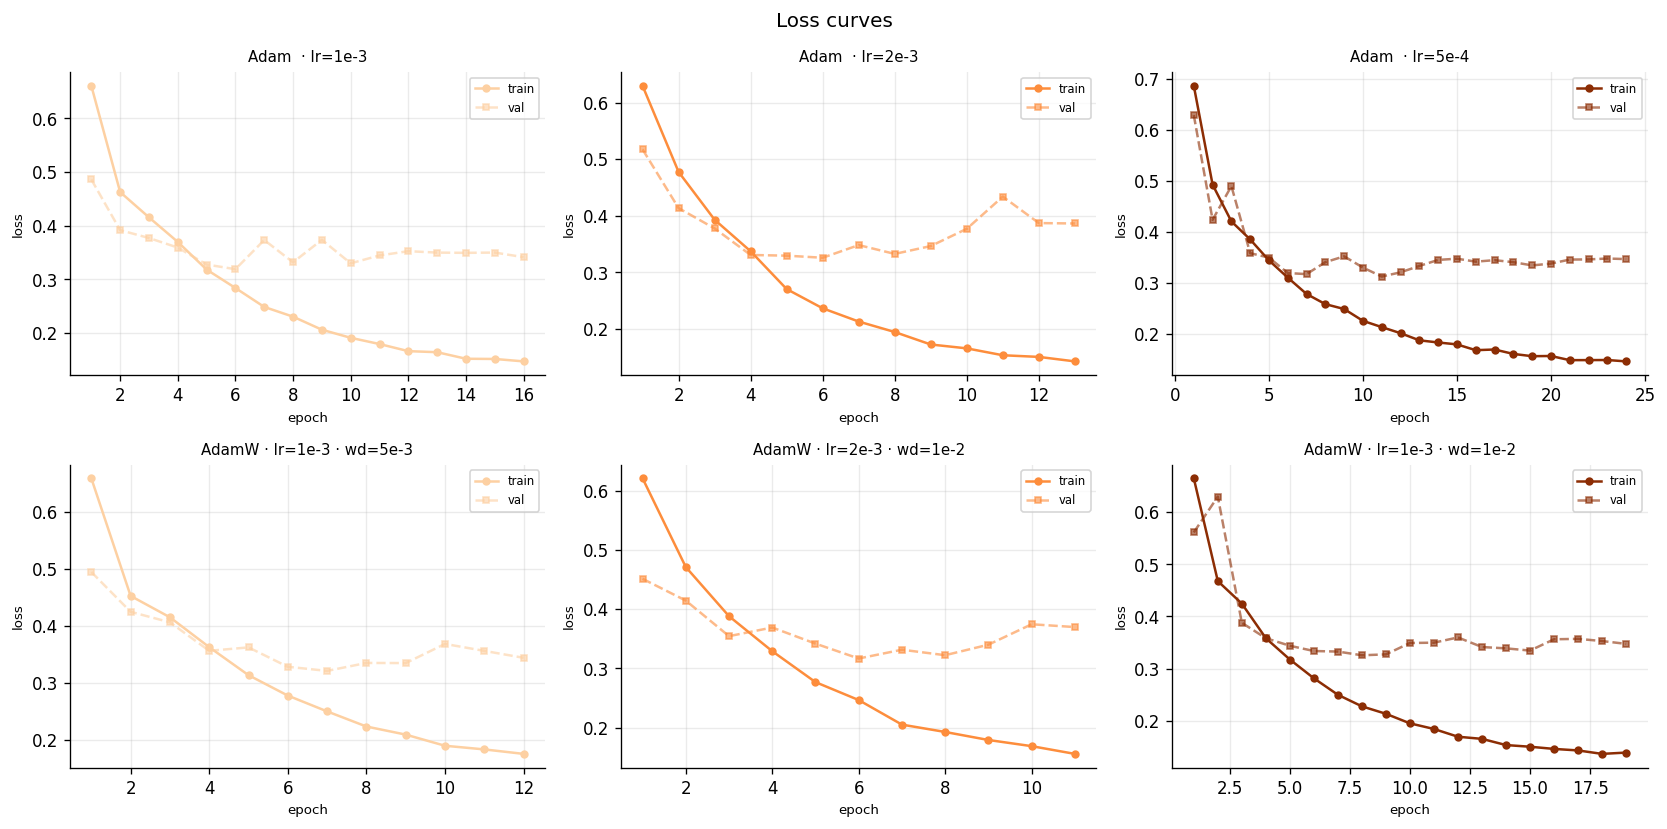

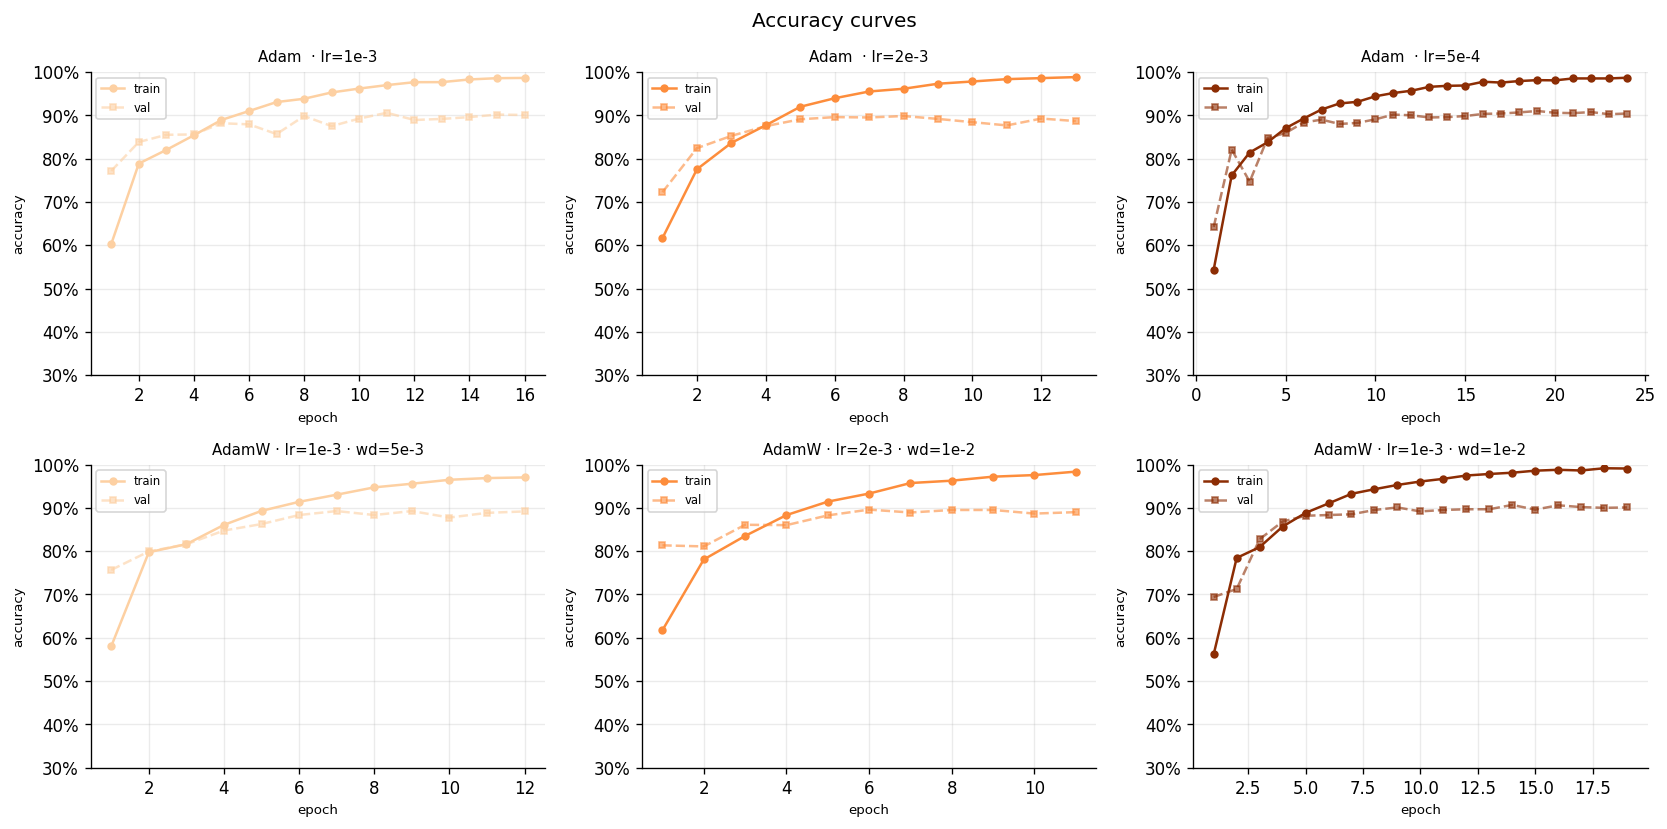

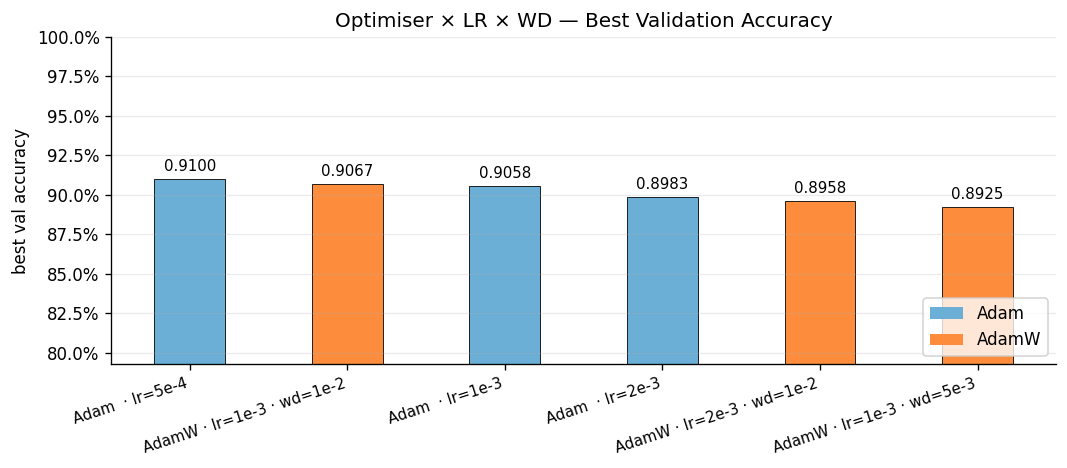

saved → loss_curves.png  acc_curves.png  comparison.png


In [47]:
n_runs   = len(run_log)
adam_pal = ['#c6dbef', '#6baed6', '#084594']
adamw_pal= ['#fdd0a2', '#fd8d3c', '#8c2d04']
pal      = adamw_pal * 3 + [adam_pal[1]]   # matches new GRID order (5 AdamW, 1 Adam)


def _ax_curves(ax, r, col, metric):
    ep_x = range(1, len(r['hist'][f'tr_{metric}']) + 1)   # adapts to early stop
    ax.plot(ep_x, r['hist'][f'tr_{metric}'], '-o',  color=col, ms=4, label='train')
    ax.plot(ep_x, r['hist'][f'va_{metric}'], '--s', color=col, ms=4, alpha=.6, label='val')
    ax.set_title(r['tag'], fontsize=9)
    ax.set_xlabel('epoch', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=.25)


# ── loss grid ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, r, c in zip(axes.flat, run_log, pal):
    _ax_curves(ax, r, c, 'loss')
    ax.set_ylabel('loss', fontsize=8)
plt.suptitle('Loss curves', fontsize=12); plt.tight_layout()
plt.savefig('loss_curves.png', bbox_inches='tight'); plt.show()

# ── accuracy grid ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, r, c in zip(axes.flat, run_log, pal):
    _ax_curves(ax, r, c, 'acc')
    ax.set_ylabel('accuracy', fontsize=8)
    ax.set_ylim(.3, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.suptitle('Accuracy curves', fontsize=12); plt.tight_layout()
plt.savefig('acc_curves.png', bbox_inches='tight'); plt.show()

# ── bar comparison ────────────────────────────────────────────────────────────
ranked = sorted(run_log, key=lambda r: r['best_acc'], reverse=True)
tags   = [r['tag']      for r in ranked]
accs   = [r['best_acc'] for r in ranked]
bpal   = [adam_pal[1] if r['opt'] == 'Adam' else adamw_pal[1] for r in ranked]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(tags, accs, color=bpal, edgecolor='k', lw=.5, width=.45)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_ylim(min(accs) - .1, 1.0)
ax.set_xticklabels(tags, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('best val accuracy')
ax.set_title('Optimiser × LR × WD — Best Validation Accuracy')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.grid(axis='y', alpha=.25)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(fc=adam_pal[1],  label='Adam'),
                   Patch(fc=adamw_pal[1], label='AdamW')], loc='lower right')
plt.tight_layout(); plt.savefig('comparison.png', bbox_inches='tight'); plt.show()

print("saved → loss_curves.png  acc_curves.png  comparison.png")

### Evaluate Best Model & Save

saved model.pt  (18.56 MB)   run: Adam  · lr=5e-4

              precision    recall  f1-score   support

     foxnews     0.9212    0.8967    0.9088       600
     nbcnews     0.8994    0.9233    0.9112       600

    accuracy                         0.9100      1200
   macro avg     0.9103    0.9100    0.9100      1200
weighted avg     0.9103    0.9100    0.9100      1200



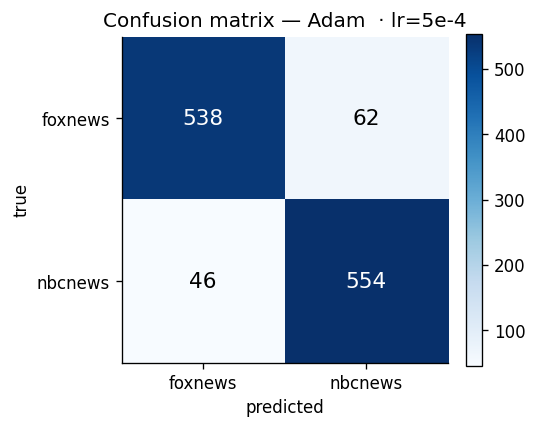

saved → confusion.png


In [48]:
# ── reload best weights ───────────────────────────────────────────────────────
net_best = _new_model()
net_best.load_state_dict({k: v.to(DEVICE) for k, v in top['snap'].items()})

torch.save({'model': net_best.state_dict(), 'vocab': tok._w2i}, CFG['ckpt'])
mb = os.path.getsize(CFG['ckpt']) / 1024**2
print(f"saved {CFG['ckpt']}  ({mb:.2f} MB)   run: {top['tag']}")

# ── classification report ─────────────────────────────────────────────────────
_, _, y_hat, y_true = probe(net_best, dl_va)

print("\n" + classification_report(
    y_true, y_hat,
    target_names=list(CFG['cls_names'].values()),
    digits=4,
))

# ── confusion matrix ──────────────────────────────────────────────────────────
cm  = confusion_matrix(y_true, y_hat)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ticks = list(CFG['cls_names'].values())
ax.set(xticks=[0,1], yticks=[0,1],
       xticklabels=ticks, yticklabels=ticks,
       xlabel='predicted', ylabel='true',
       title=f'Confusion matrix — {top["tag"]}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=13,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax, fraction=.046)
plt.tight_layout(); plt.savefig('confusion.png', bbox_inches='tight'); plt.show()
print("saved → confusion.png")